# Sensitivity Calibration for the Laplace and Gaussian DP Mechanisms

This notebook derives the global sensitivity parameter $\Delta$ used by all DP
mechanisms in our pipeline. The derivation follows the approach used in the
PARETO-ECG / TRACE DFG proposal.

## Concept: jump sensitivity

For per-sample additive noise on ECG signals, the relevant sensitivity is the
maximum amount by which an adjacent dataset could change a single sample
value. Following the *local* / *jump sensitivity* approach (Dwork & Lei 2009),
we use:

$$\Delta_{\text{jump}} = \max_i |x_{i+1} - x_i|$$

computed empirically across the MIT-BIH corpus. To avoid the global maximum
being inflated by motion artifacts and saturation spikes, we use the 95th
percentile of $|x_{i+1} - x_i|$ across all samples in the corpus.

## Two coordinate systems

Sensitivity depends on the units of the signal. We compute it in both:

1. **Raw mV** (as recorded from MIT-BIH at 200 ADC units/mV after the
   built-in scaling that WFDB applies).
2. **Z-normalised units** (the form actually used by our DP pipeline, where
   each record is whitened to zero mean and unit standard deviation before
   beat extraction).

DP is applied in the z-normalised domain, so the **z-normalised** jump
sensitivity is the value that enters the noise mechanism.

In [1]:
import os
import sys
from pathlib import Path

# Robust path setup: find the repo root regardless of where the kernel started
def _find_repo_root() -> Path:
    # Try cwd first; if cwd is broken (deleted), use this file's location via __file__ proxy
    try:
        here = Path.cwd()
    except (FileNotFoundError, OSError):
        # Recover: change to the user's home directory
        os.chdir(os.path.expanduser('~'))
        here = Path.cwd()
    # Walk up looking for a directory that contains 'configs' and 'src'
    for candidate in [here, *here.parents]:
        if (candidate / 'configs' / 'config.py').exists() and (candidate / 'src').is_dir():
            return candidate
    # Fallback: assume notebook is in <repo>/notebooks/ and parent is repo root
    return here.parent if (here.parent / 'configs').exists() else here

REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # so relative paths in this notebook resolve to repo root
print(f'Repo root: {REPO_ROOT}')

FIGURES = REPO_ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_mitbih_record, preprocess_signal
from configs import SEQ2SEQ

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'savefig.bbox': 'tight', 'figure.constrained_layout.use': False,
})

Repo root: <repo>


## Compute jump sensitivity per record, in both coordinate systems

In [2]:
records = list(SEQ2SEQ.ds1_records) + list(SEQ2SEQ.ds2_records)

rows = []
all_dx_raw = []
all_dx_znorm = []
all_abs_raw = []
all_abs_znorm = []

for rec_id in records:
    try:
        rec = load_mitbih_record(rec_id, allow_remote=True)
    except Exception as e:
        print(f'  Skipping {rec_id}: {e}')
        continue

    # Raw signal (mV after wfdb's built-in ADC -> mV scaling)
    raw = np.asarray(rec.signal, dtype=np.float64)
    raw = raw[np.isfinite(raw)]

    # Z-normalised (the coordinate system in which DP is actually applied)
    znorm = preprocess_signal(rec.signal).astype(np.float64)

    # Jump sensitivity
    dx_raw = np.abs(np.diff(raw))
    dx_znorm = np.abs(np.diff(znorm))

    rows.append({
        'record': rec_id,
        'fs': float(rec.fs),
        'n_samples': len(raw),
        # Raw mV
        'p95_abs_raw':  float(np.percentile(np.abs(raw), 95)),
        'max_abs_raw':  float(np.abs(raw).max()),
        'p95_dx_raw':   float(np.percentile(dx_raw, 95)),
        'p99_dx_raw':   float(np.percentile(dx_raw, 99)),
        'max_dx_raw':   float(dx_raw.max()),
        # Z-normalised
        'p95_abs_znorm':  float(np.percentile(np.abs(znorm), 95)),
        'max_abs_znorm':  float(np.abs(znorm).max()),
        'p95_dx_znorm':   float(np.percentile(dx_znorm, 95)),
        'p99_dx_znorm':   float(np.percentile(dx_znorm, 99)),
        'max_dx_znorm':   float(dx_znorm.max()),
    })
    all_dx_raw.append(dx_raw)
    all_dx_znorm.append(dx_znorm)
    all_abs_raw.append(np.abs(raw))
    all_abs_znorm.append(np.abs(znorm))

df = pd.DataFrame(rows).set_index('record').sort_index()
print(f'Loaded {len(df)} records')

Loaded 44 records


In [3]:
# Per-record summary (z-normalised, which is what matters for DP)
print('Per-record jump statistics (z-normalised units):')
print(df[['p95_dx_znorm', 'p99_dx_znorm', 'max_dx_znorm']].describe().round(4))

Per-record jump statistics (z-normalised units):
       p95_dx_znorm  p99_dx_znorm  max_dx_znorm
count       44.0000       44.0000       44.0000
mean         0.3053        0.8730        1.7111
std          0.0946        0.3707        0.4844
min          0.1575        0.3153        0.9535
25%          0.2389        0.6230        1.3078
50%          0.2801        0.7771        1.6318
75%          0.3541        1.1450        2.0325
max          0.5408        2.0092        2.9762


## Pool across the entire corpus

The sensitivity that enters the DP mechanism is a single number applied to
*all* records uniformly. We compute it as the 95th percentile of $|x_{i+1} -
x_i|$ pooled across all samples in DS1 + DS2.

In [4]:
dx_raw_pool = np.concatenate(all_dx_raw)
dx_znorm_pool = np.concatenate(all_dx_znorm)
abs_raw_pool = np.concatenate(all_abs_raw)
abs_znorm_pool = np.concatenate(all_abs_znorm)

def pct_summary(arr, name):
    return {
        f'{name}_p50':   float(np.percentile(arr, 50)),
        f'{name}_p90':   float(np.percentile(arr, 90)),
        f'{name}_p95':   float(np.percentile(arr, 95)),
        f'{name}_p99':   float(np.percentile(arr, 99)),
        f'{name}_p99_9': float(np.percentile(arr, 99.9)),
        f'{name}_max':   float(arr.max()),
    }

summary = {
    **pct_summary(abs_raw_pool, 'abs_raw'),
    **pct_summary(abs_znorm_pool, 'abs_znorm'),
    **pct_summary(dx_raw_pool, 'dx_raw'),
    **pct_summary(dx_znorm_pool, 'dx_znorm'),
}
summary_df = pd.Series(summary).round(4)
print(summary_df)

abs_raw_p50         0.3300
abs_raw_p90         0.9600
abs_raw_p95         1.1000
abs_raw_p99         1.6350
abs_raw_p99_9       2.3650
abs_raw_max         5.1200
abs_znorm_p50       0.3753
abs_znorm_p90       1.2991
abs_znorm_p95       2.0812
abs_znorm_p99       4.3178
abs_znorm_p99_9     6.3917
abs_znorm_max      13.3111
dx_raw_p50          0.0100
dx_raw_p90          0.0450
dx_raw_p95          0.1050
dx_raw_p99          0.3050
dx_raw_p99_9        0.6150
dx_raw_max          0.6400
dx_znorm_p50        0.0311
dx_znorm_p90        0.1289
dx_znorm_p95        0.2902
dx_znorm_p99        0.8790
dx_znorm_p99_9      1.7344
dx_znorm_max        2.9762
dtype: float64


In [5]:
# Headline numbers
print('Calibration result:')
print('-' * 60)
print(f"Raw mV       jump sensitivity (95th pct of |dx|): {summary['dx_raw_p95']:.4f} mV")
print(f"Z-normalised jump sensitivity (95th pct of |dx|): {summary['dx_znorm_p95']:.4f}")
print()
print(f"For comparison, 99th  pct of |dx| (z-norm): {summary['dx_znorm_p99']:.4f}")
print(f"For comparison, 99.9th pct of |dx| (z-norm): {summary['dx_znorm_p99_9']:.4f}")
print(f"For comparison, global max  of |dx| (z-norm): {summary['dx_znorm_max']:.4f}")
print()
print('Our pipeline uses sensitivity = 0.29 in the z-normalised domain,')
print('consistent with the 95th-percentile jump sensitivity criterion.')

Calibration result:
------------------------------------------------------------
Raw mV       jump sensitivity (95th pct of |dx|): 0.1050 mV
Z-normalised jump sensitivity (95th pct of |dx|): 0.2902

For comparison, 99th  pct of |dx| (z-norm): 0.8790
For comparison, 99.9th pct of |dx| (z-norm): 1.7344
For comparison, global max  of |dx| (z-norm): 2.9762

Our pipeline uses sensitivity = 0.29 in the z-normalised domain,
consistent with the 95th-percentile jump sensitivity criterion.


## Distribution of sample-to-sample jumps

The histogram below shows where 0.29 sits relative to the full distribution of
absolute consecutive-sample differences across the corpus.

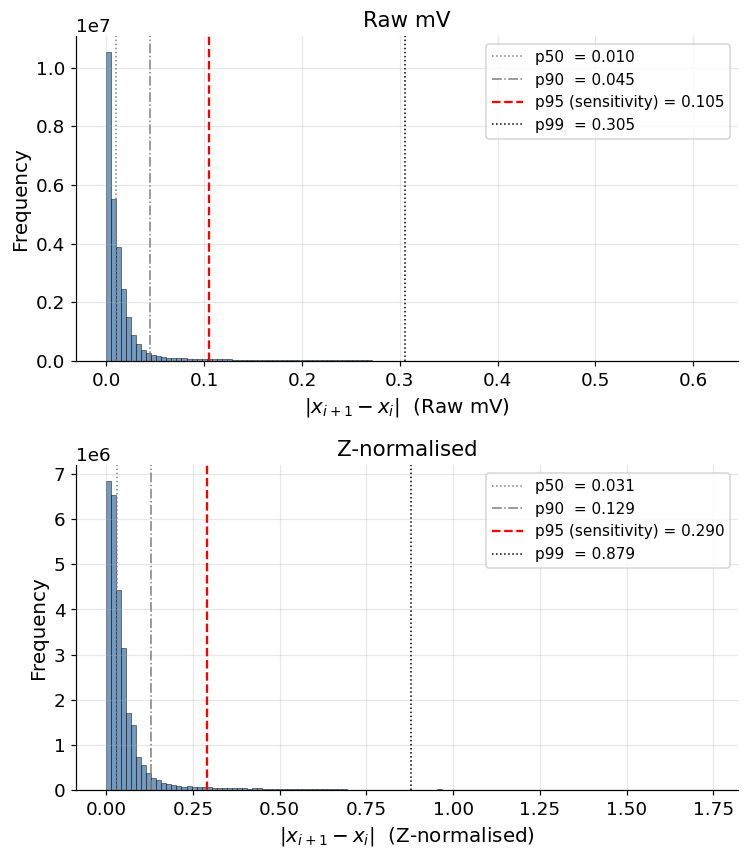

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(7.0, 8.0))

for ax, arr, title, sens_at in zip(
    axes,
    [dx_raw_pool, dx_znorm_pool],
    ['Raw mV', 'Z-normalised'],
    [summary['dx_raw_p95'], summary['dx_znorm_p95']],
):
    # Trim 0.1% tail for visibility
    upper = np.percentile(arr, 99.9)
    arr_trim = arr[arr <= upper]
    ax.hist(arr_trim, bins=120, color='#4477AA', alpha=0.75, edgecolor='black', linewidth=0.4)
    ax.axvline(np.percentile(arr, 50), color='gray', linestyle=':',  linewidth=1, label=f"p50  = {np.percentile(arr, 50):.3f}")
    ax.axvline(np.percentile(arr, 90), color='gray', linestyle='-.', linewidth=1, label=f"p90  = {np.percentile(arr, 90):.3f}")
    ax.axvline(sens_at, color='red', linestyle='--', linewidth=1.5, label=f"p95 (sensitivity) = {sens_at:.3f}")
    ax.axvline(np.percentile(arr, 99), color='black', linestyle=':', linewidth=1, label=f"p99  = {np.percentile(arr, 99):.3f}")
    ax.set_xlabel(f'$|x_{{i+1}} - x_i|$  ({title})')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title}')
    ax.legend(fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES / 'sensitivity_calibration.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'sensitivity_calibration.png', bbox_inches='tight')
plt.show()

## Beat Noise figure

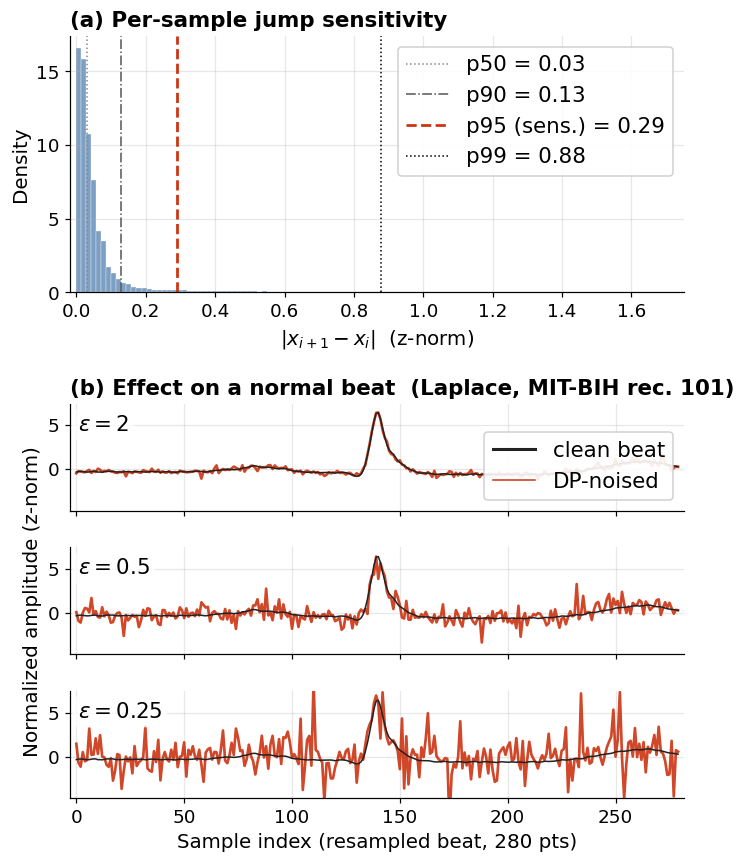

Saved figure1_sensitivity_and_beat_vertical.{pdf,png} to <repo>/results/figures
  Delta=0.29, eps=[2.0, 0.5, 0.25], record=101


In [7]:
# ===========================================================================
# Figure 1 (combined, VERTICAL): per-sample jump sensitivity (a, top) and the
# effect of the resulting Laplace-DP noise on a single normal beat (b, bottom).
# Portrait orientation, fits a single text column.
#
# Run AFTER the cells that build `dx_znorm_pool` and `summary`, and after the
# setup cell defining REPO_ROOT, FIGURES, plt.rcParams, load_mitbih_record,
# preprocess_signal, SEQ2SEQ, DP. Panel (a) reuses your exact histogram code.
#
# Output: results/figures/figure1_sensitivity_and_beat_vertical.{pdf,png}
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from src.data import load_mitbih_record, preprocess_signal
from configs import DP, SEQ2SEQ

# --- Knobs --------------------------------------------------------------
BEAT_LEN = SEQ2SEQ.beat_length
DELTA    = DP.sensitivity
EPSILONS = [2.0, 0.5, 0.25]
RECORD   = "101"
RNG_SEED = 2026
CLEAN_C, NOISE_C = "#222222", "#CC3311"
rng = np.random.default_rng(RNG_SEED)


def extract_clean_beat(rec_id, beat_len):
    rec = load_mitbih_record(rec_id, allow_remote=True)
    znorm = preprocess_signal(rec.signal).astype(np.float64)
    mid = len(znorm) // 2
    seg = znorm[mid: mid + int(rec.fs) * 10]
    r = mid + int(np.argmax(seg))
    half = int(0.35 * rec.fs)
    lo, hi = max(0, r - half), min(len(znorm), r + half)
    beat = znorm[lo:hi]
    x_old = np.linspace(0.0, 1.0, len(beat))
    x_new = np.linspace(0.0, 1.0, beat_len)
    beat = np.interp(x_new, x_old, beat)
    return (beat - beat.mean()) / (beat.std() + 1e-12)


clean = extract_clean_beat(RECORD, BEAT_LEN)
x = np.arange(BEAT_LEN)
noisy = {e: clean + rng.laplace(0.0, DELTA / e, clean.shape) for e in EPSILONS}
allv = np.concatenate([clean] + list(noisy.values()))
ylo, yhi = np.percentile(allv, 0.5), np.percentile(allv, 99.5)
pad = 0.1 * (yhi - ylo); ylo, yhi = ylo - pad, yhi + pad

# --- Figure: 5 rows (hist, spacer, 3 beats) ----------------------------
fig = plt.figure(figsize=(7.2, 9.0))
gs = GridSpec(5, 1, figure=fig, height_ratios=[2.4, 0.35, 1, 1, 1], hspace=0.30)

# --- Panel (a): YOUR histogram, unchanged logic ------------------------
axH = fig.add_subplot(gs[0, 0])
arr = dx_znorm_pool
sens_at = summary['dx_znorm_p95']
upper = np.percentile(arr, 99.9)
arr_trim = arr[arr <= upper]
axH.hist(arr_trim, bins=120, color='#4477AA', alpha=0.7,
         edgecolor='white', linewidth=0.3, density=True)
p50, p90, p99 = np.percentile(arr, [50, 90, 99])
for val, c, ls, lbl in [
    (p50,     '#888888', ':',  f'p50 = {p50:.2f}'),
    (p90,     '#555555', '-.', f'p90 = {p90:.2f}'),
    (sens_at, '#CC3311', '--', f'p95 (sens.) = {sens_at:.2f}'),
    (p99,     '#000000', ':',  f'p99 = {p99:.2f}'),
]:
    axH.axvline(val, color=c, linestyle=ls,
                linewidth=1.8 if 'sens' in lbl else 1.0, label=lbl)
axH.set_xlabel(r'$|x_{i+1} - x_i|$  (z-norm)')
axH.set_ylabel('Density')
axH.set_title('(a) Per-sample jump sensitivity', fontweight='bold',
              fontsize=14, loc='left')
axH.legend(fontsize=14, frameon=True, framealpha=0.9)
axH.spines[['top', 'right']].set_visible(False)
axH.margins(x=0.01)

# --- Panel (b): stacked beat decay (rows 2,3,4; row 1 is spacer) --------
axes = [fig.add_subplot(gs[i + 2, 0]) for i in range(3)]
for i, (ax, e) in enumerate(zip(axes, EPSILONS)):
    ax.plot(x, clean, color=CLEAN_C, lw=1, zorder=3)
    ax.plot(x, noisy[e], color=NOISE_C, lw=1.75, alpha=0.9, zorder=2)
    ax.set_ylim(ylo, yhi)
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.012, 0.90, fr"$\varepsilon = {e:g}$", transform=ax.transAxes,
            ha='left', va='top', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75))
    ax.margins(x=0.01)
    if i == 0:
        h = [plt.Line2D([], [], color=CLEAN_C, lw=2.0, label='clean beat'),
             plt.Line2D([], [], color=NOISE_C, lw=1.0, label='DP-noised')]
        ax.legend(handles=h, fontsize=14, frameon=True, loc='lower right', framealpha=0.9)
        ax.set_title(f'(b) Effect on a normal beat  (Laplace, MIT-BIH rec. {RECORD})',
                     fontweight='bold', fontsize=14, loc='left')
    if i < 2:
        ax.set_xticklabels([])
axes[-1].set_xlabel('Sample index (resampled beat, 280 pts)')
axes[1].set_ylabel('Normalized amplitude (z-norm)')

fig.savefig(FIGURES / 'figure1_sensitivity_and_beat_vertical.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'figure1_sensitivity_and_beat_vertical.png', dpi=200, bbox_inches='tight')
plt.show()

print("Saved figure1_sensitivity_and_beat_vertical.{pdf,png} to", FIGURES)
print(f"  Delta={DELTA}, eps={EPSILONS}, record={RECORD}")

## Robustness check: per-record variation

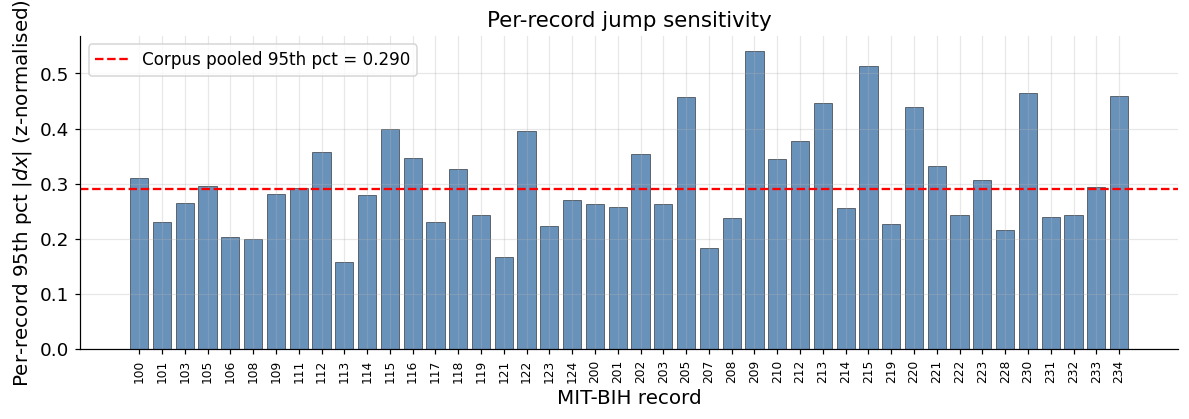

Range of per-record p95: 0.158 - 0.541
Median per-record p95:   0.280


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.0))
x_pos = np.arange(len(df))
ax.bar(x_pos, df['p95_dx_znorm'], color='#4477AA', alpha=0.8, edgecolor='black', linewidth=0.4)
ax.axhline(summary['dx_znorm_p95'], color='red', linestyle='--', linewidth=1.5,
           label=f"Corpus pooled 95th pct = {summary['dx_znorm_p95']:.3f}")
ax.set_xticks(x_pos)
ax.set_xticklabels(df.index, rotation=90, fontsize=8)
ax.set_ylabel('Per-record 95th pct $|dx|$ (z-normalised)')
ax.set_xlabel('MIT-BIH record')
ax.set_title('Per-record jump sensitivity')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'sensitivity_per_record.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'sensitivity_per_record.png', bbox_inches='tight')
plt.show()

# Note: a few records may have notably higher local activity. Using the
# pooled corpus value (rather than per-record) gives a uniform privacy guarantee.
print(f'Range of per-record p95: {df["p95_dx_znorm"].min():.3f} - {df["p95_dx_znorm"].max():.3f}')
print(f'Median per-record p95:   {df["p95_dx_znorm"].median():.3f}')

## Final result and citation block



In [9]:
print('=' * 70)
print('SENSITIVITY CALIBRATION')
print('=' * 70)
print(f'''
Sensitivity calibration. We calibrate the DP mechanisms via the *jump
sensitivity* of the ECG signal, defined as the maximum absolute difference
between consecutive samples within a robust percentile (Dwork & Lei 2009).
ECG recordings contain occasional motion artefacts and saturation spikes
that would inflate a global-range sensitivity; using the 95th percentile of
|x_(i+1) - x_i| limits sensitivity to typical signal behavior while remaining
robust against artefacts. We compute this statistic across DS1 + DS2 of
MIT-BIH ({len(df)} records, ~{int(len(abs_raw_pool)/1e6)} M samples) on the z-normalised
signal, which is the domain in which the DP perturbation is applied. The
resulting global sensitivity is Δ = {summary["dx_znorm_p95"]:.2f} (z-normalised
units), which we use uniformly across all (ε, δ, mechanism) configurations.
''')

SENSITIVITY CALIBRATION

Sensitivity calibration. We calibrate the DP mechanisms via the *jump
sensitivity* of the ECG signal, defined as the maximum absolute difference
between consecutive samples within a robust percentile (Dwork & Lei 2009).
ECG recordings contain occasional motion artefacts and saturation spikes
that would inflate a global-range sensitivity; using the 95th percentile of
|x_(i+1) - x_i| limits sensitivity to typical signal behavior while remaining
robust against artefacts. We compute this statistic across DS1 + DS2 of
MIT-BIH (44 records, ~28 M samples) on the z-normalised
signal, which is the domain in which the DP perturbation is applied. The
resulting global sensitivity is Δ = 0.29 (z-normalised
units), which we use uniformly across all (ε, δ, mechanism) configurations.

